### Load data
: 10000 sample item

In [21]:
import pandas as pd

archive_path = 'archive/train.csv'
df = pd.read_csv(archive_path, header=None, names=['polarity', 'title', 'text'])
df = df.sample(10000,random_state=42).reset_index(drop=True)
print(df.shape)
print(df.value_counts())
print(df.head())


(10000, 3)
polarity  title                                                                  text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
1         "At first, you're going to have to use interruption marketin           He admits, and so his whole theory seems a bit b.s. after he's just said that in today's market you cannot use interruption marketing. A little too high on his own thing, 

In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   polarity  10000 non-null  int64 
 1   title     9999 non-null   object
 2   text      10000 non-null  object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB
None


### Data-preprocess
- entire sentence for tfidf: content=title+txt
- label y

In [23]:
df['label'] = df['polarity'].map({
    1:'negative',
    2:'positive',
})
print(df['label'].value_counts())
df['content'] = df['title'] + ' ' + df['text']
df = df.dropna(subset=['content', 'label'])
print(df['label'].value_counts())

label
positive    5046
negative    4954
Name: count, dtype: int64
label
positive    5045
negative    4954
Name: count, dtype: int64


              precision    recall  f1-score   support

    negative       0.83      0.81      0.82       991
    positive       0.82      0.83      0.83      1009

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



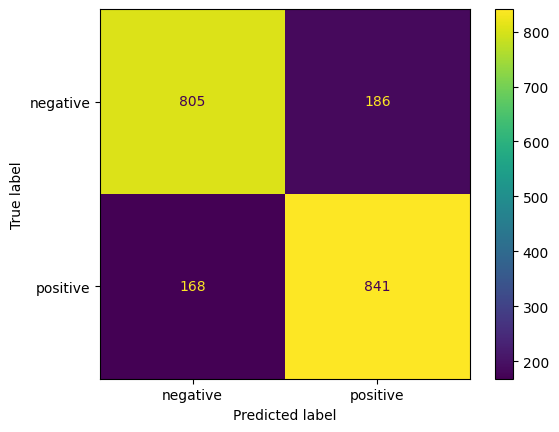

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X, y = df['content'], df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
)
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

model = MultinomialNB().fit(X_train, y_train)

pred_y = model.predict(X_test)
print(classification_report(
    y_test, pred_y
))
cm = confusion_matrix(y_test, pred_y, labels=['negative', 'positive'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['negative', 'positive']
)
disp.plot()



### For other testing data used function review_sentiment()

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

def review_sentiment(review:str):
    review_tfidf = tfidf.transform([review])
    pred_y = model.predict(review_tfidf)[0]
    pred_y_prob = model.predict_proba(review_tfidf)[0]
    classes = model.classes_
    print(f"\nInput:{review}")
    print(f"Predict:{pred_y}")
    for c, p in zip(classes, pred_y_prob):
        print(f"class:{c}, prob:{p}")
    return{
        'prediction':pred_y,
        'probability':dict(zip(classes, pred_y_prob))
    }

### TESTING
1. Absolutely love this place — the staff were warm and attentive, the food came out fast and tasted amazing. Would 100% recommend to anyone visiting the area.**(Positive)**
2. The order arrived damaged, two items were missing, and customer support told me to 'just wait' with no follow-up. I've asked for a full refund and still haven't heard back after five days.**(negative)**
3. The packaging looks premium and the scent is nice, but $48 for something that ran out in three weeks feels like a stretch. Not sure I'd repurchase at this price point.**(middle)**
4. 😤😤😤 never again **(negative)**
5. Okay so the ambiance is genuinely lovely and the cocktails were creative — I'll give them that. But honestly the food was forgettable, the server disappeared for 40 minutes, and I left feeling like I'd wasted a Saturday night. Probably not coming back.**(negative)**

In [33]:
reviews = [
    'Absolutely love this place - the staff were warm and attentive, the food came out fast and tasted amazing. Would 100% recommend to anyone visiting the area.',
    "The order arrived damaged, two items were missing, and customer support told me to 'just wait' with no follow-up. I've asked for a full refund and still haven't heard back after five days.",
    'The packaging looks premium and the scent is nice, but $48 for something that ran out in three weeks feels like a stretch. Not sure I would repurchase at this price point.',
    '😤😤😤 never again',
    "Okay so the ambiance is genuinely lovely and the cocktails were creative. But honestly the food was forgettable, the server disappeared for 40 minutes, and I left feeling like I'd wasted a Saturday night."
]

results = [review_sentiment(r) for r in reviews]

for i, res in enumerate(results, 1):
    print(f"Item{i}: {res}")


Input:Absolutely love this place - the staff were warm and attentive, the food came out fast and tasted amazing. Would 100% recommend to anyone visiting the area.
Predict:positive
class:negative, prob:0.28513618850589023
class:positive, prob:0.7148638114941113

Input:The order arrived damaged, two items were missing, and customer support told me to 'just wait' with no follow-up. I've asked for a full refund and still haven't heard back after five days.
Predict:negative
class:negative, prob:0.7766810441632168
class:positive, prob:0.22331895583678546

Input:The packaging looks premium and the scent is nice, but $48 for something that ran out in three weeks feels like a stretch. Not sure I would repurchase at this price point.
Predict:negative
class:negative, prob:0.5742578937094365
class:positive, prob:0.4257421062905621

Input:😤😤😤 never again
Predict:positive
class:negative, prob:0.49543692961620217
class:positive, prob:0.5045630703837979

Input:Okay so the ambiance is genuinely lovely